In [15]:
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms

sys.path.append(os.path.abspath(".."))
from src.utils import apply_heavy_tailed_init, set_seed

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. GPU-Accelerated Data Loading ---
def get_gpu_mnist():
    """Loads full MNIST to GPU memory once."""
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    train_set = datasets.MNIST('../data', train=True, download=True, transform=transform)
    test_set = datasets.MNIST('../data', train=False, download=True, transform=transform)

    # Push everything to DEVICE immediately
    train_data = train_set.data.unsqueeze(1).float().to(DEVICE) / 255.0
    train_data = (train_data - 0.1307) / 0.3081
    train_labels = train_set.targets.to(DEVICE)

    test_data = test_set.data.unsqueeze(1).float().to(DEVICE) / 255.0
    test_data = (test_data - 0.1307) / 0.3081
    test_labels = test_set.targets.to(DEVICE)

    return (train_data, train_labels), (test_data, test_labels)

(train_x, train_y), (test_x, test_y) = get_gpu_mnist()

def get_gpu_fashion_mnist():
    """Loads full Fashion-MNIST to GPU memory once."""
    # Official Fashion-MNIST mean and std for normalization
    mean, std = 0.2860, 0.3530

    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((mean,), (std,))])
    train_set = datasets.FashionMNIST('../data', train=True, download=True, transform=transform)
    test_set = datasets.FashionMNIST('../data', train=False, download=True, transform=transform)

    # Push to GPU and normalize manually to match your MNIST pipeline
    train_data = train_set.data.unsqueeze(1).float().to(DEVICE) / 255.0
    train_data = (train_data - mean) / std
    train_labels = train_set.targets.to(DEVICE)

    test_data = test_set.data.unsqueeze(1).float().to(DEVICE) / 255.0
    test_data = (test_data - mean) / std
    test_labels = test_set.targets.to(DEVICE)

    return (train_data, train_labels), (test_data, test_labels)

# To switch tasks, simply toggle the comment on these lines:
# (train_x, train_y), (test_x, test_y) = get_gpu_fashion_mnist()

def get_task_data(x, y, digits):
    mask = torch.stack([y == d for d in digits]).sum(0).bool()
    return x[mask], y[mask]

# --- 2. Model & Ebbinghaus Logic ---
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 400, bias=False),
            nn.Tanh(),
            nn.Linear(400, 400, bias=False),
            nn.Tanh(),
            nn.Linear(400, 10, bias=False)
        )

    def forward(self, x):
        return self.fc(x)

    def get_pre_activations(self, x):
        """Intercepts pre-activation state data matching layer keys explicitly."""
        pre_acts = {}

        # Layer 1
        x = self.fc[0](x)
        x = self.fc[1](x)
        pre_acts['fc1'] = x.clone()

        # Layer 2
        x = self.fc[2](x)
        x = self.fc[3](x)
        pre_acts['fc2'] = x.clone()

        # Layer 3
        x = self.fc[4](x)
        x = self.fc[5](x)
        pre_acts['fc3'] = x.clone()

        return pre_acts

    def get_layer_weights(self):
        """Returns linear transformation weight tensors mapped explicitly to activation keys."""
        return {
            'fc1': self.fc[1].weight,
            'fc2': self.fc[3].weight,
            'fc3': self.fc[5].weight
        }

# --- 3. Eval Function for BWT/FWT ---
def evaluate(model, tasks_data):
    model.eval()
    accs = []
    with torch.no_grad():
        for tx, ty in tasks_data:
            out = model(tx)
            acc = (out.argmax(1) == ty).float().mean().item()
            accs.append(acc)
    model.train()
    return accs

def check_gradient_direction(linear_layers, feature_list):
    """
    Measures gradient geometry across past task subspaces.
    Extracts directional alignment (parallel) and vector magnitudes (parallel vs orthogonal)
    normalized to total gradient energy for 2D Cartesian phase portraits.
    """
    if feature_list is None:
        return None

    layer_stats = {}
    with torch.no_grad():
        for i, layer in enumerate(linear_layers):
            if i >= len(feature_list) or feature_list[i] is None or layer.weight.grad is None:
                continue

            grad = layer.weight.grad          # Shape: (Out, In)
            basis = feature_list[i]         # Shape: (In, K)

            # --- 1. COMPUTE TOTAL GRADIENT METRICS ---
            total_norm = torch.linalg.norm(grad).item()
            if total_norm == 0:
                layer_stats[f'layer_{i}'] = {
                    'net_alignment': 0.0, 'pos_energy': 0.0, 'neg_energy': 0.0,
                    'total_norm': 0.0, 'parallel_norm': 0.0, 'orthogonal_norm': 0.0,
                    'x_parallel_normalized': 0.0, 'y_orthogonal_normalized': 0.0
                }
                continue

            # --- RE-ENGINEERED TRUE SUBSPACE ALIGNMENT ---
            # Isolate the parallel gradient vector component
            parallel_grad = torch.mm(torch.mm(grad, basis), basis.t())
            orthogonal_grad = grad - parallel_grad
            parallel_norm = torch.linalg.norm(parallel_grad).item()
            orthogonal_norm = torch.linalg.norm(orthogonal_grad).item()

            if parallel_norm > 0:
                # 1. Project the current weights into the exact same past task subspace
                parallel_weight = torch.mm(torch.mm(layer.weight, basis), basis.t())

                # 2. Compute the true Frobenius inner product (Matrix Dot Product)
                # This measures if the update vector points WITH or AGAINST the existing weight vector
                # Formula: trace(A.T @ B)
                dot_product = torch.sum(parallel_grad * parallel_weight).item()

                # 3. Normalize the score by the magnitudes to get a true Cosine Similarity (-1 to +1)
                weight_norm = torch.linalg.norm(parallel_weight).item()
                if weight_norm > 0:
                    true_alignment = dot_product / (parallel_norm * weight_norm)
                else:
                    true_alignment = 0.0
            else:
                true_alignment = 0.0

            # --- MAP TO CLEAN VISUAL COORDINATES ---
            # X: The true cosine direction of the update multiplied by its energy share
            x_coord = true_alignment * (parallel_norm / total_norm)

            # Y: The pure orthogonal exploration volume share
            y_coord = orthogonal_norm / total_norm

            layer_stats[f'layer_{i}'] = {
                # Directional Signs (Legacy tracking for time overlay)
                'net_alignment': true_alignment,

                # Raw Vector Metrics (Energy Magnitudes)
                'total_norm': total_norm,
                'parallel_norm': parallel_norm,
                'orthogonal_norm': orthogonal_norm,

                # Phase Portrait Coordinates (Unit Bound)
                'x_parallel_normalized': x_coord,      # Range: -1.0 to +1.0
                'y_orthogonal_normalized': y_coord      # Range:  0.0 to +1.0
            }

    return layer_stats

# --- New Configuration ---
EVAL_EVERY_N_BATCHES = 50

class MetricsTracker:
    def __init__(self):
        self.history = {
            'steps': [],
            'accuracies': [], # List of lists [acc_t0, acc_t1, ...]
            'losses': [],
            'stability_means': [],
            'stability_max': []
        }

    def log(self, step, accs, loss, stability_list):
        self.history['steps'].append(step)
        self.history['accuracies'].append(accs)
        self.history['losses'].append(loss)

        # Track stability stats to see the "Inertia" growth
        all_s = torch.cat([s.view(-1) for s in stability_list])
        self.history['stability_means'].append(all_s.mean().item())
        self.history['stability_max'].append(all_s.max().item())

class AlignmentTracker:
    def __init__(self, num_tasks=5):
        self.steps = []
        self.task_boundaries = []

        # Core metric histories organized by layer keys (e.g., 'layer_0', 'layer_1')
        self.net_alignments = {}
        self.total_norm = {}
        self.parallel_norm = {}
        self.orthogonal_norm = {}
        self.x_parallel_normalized = {}
        self.y_orthogonal_normalized = {}

        # Track accuracy histories as separate step-aligned lists
        self.num_tasks = num_tasks
        self.accuracies = {f'task_{i}': [] for i in range(num_tasks)}
        self.acc_steps = []  # Timeline tracking for evaluation steps

    def log_gradients(self, step, stats):
        """
        Accepts the full stats dictionary across all calculated layers
        and appends metrics into layer-specific tracking arrays dynamically.
        """
        if not stats:
            return

        self.steps.append(step)

        for layer_key, layer_metrics in stats.items():
            # Dynamically initialize sub-lists for newly encountered layer names
            if layer_key not in self.net_alignments:
                self.net_alignments[layer_key] = []
                self.total_norm[layer_key] = []
                self.parallel_norm[layer_key] = []
                self.orthogonal_norm[layer_key] = []
                self.x_parallel_normalized[layer_key] = []
                self.y_orthogonal_normalized[layer_key] = []

            # Append metrics to the active layer profile
            self.net_alignments[layer_key].append(layer_metrics['net_alignment'])
            self.total_norm[layer_key].append(layer_metrics['total_norm'])
            self.parallel_norm[layer_key].append(layer_metrics['parallel_norm'])
            self.orthogonal_norm[layer_key].append(layer_metrics['orthogonal_norm'])
            self.x_parallel_normalized[layer_key].append(layer_metrics['x_parallel_normalized'])
            self.y_orthogonal_normalized[layer_key].append(layer_metrics['y_orthogonal_normalized'])

    def log_accuracies(self, step, acc_list):
        self.acc_steps.append(step)
        for i, acc in enumerate(acc_list):
            if i < self.num_tasks:
                self.accuracies[f'task_{i}'].append(acc)

In [21]:
# --- 2. MVP Hyperparameters ---
TASKS = [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]
LR = 1e-3
BATCH_SIZE = 64
EPOCHS_PER_TASK = 10

# Jacobian Landscape Hyperparameters
LAMBDA_REG = 10000.0       # Strength multiplier for the past-task memory constraint
CALIB_SAMPLE_SIZE = 256 # Scale of the anchor batch to evaluate the landscape function

# --- 3. Initialization ---
set_seed(42)
model = SimpleMLP().to(DEVICE)
model = apply_heavy_tailed_init(model=model, alpha=1.2, g=1.0)
optimizer = optim.SGD(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()
align_tracker = AlignmentTracker(num_tasks=len(TASKS))

# Cache references to your linear modules for fast gradient manipulation
linear_layers = [model.fc[1], model.fc[3], model.fc[5]]

# Pull down the pre-loaded data arrays from your setup
(train_x, train_y), (test_x, test_y) = get_gpu_mnist()
all_test_tasks = [get_task_data(test_x, test_y, t) for t in TASKS]

# Dictionary tracking cumulative anchor maps across all past task landscapes
jacobian_anchors = {}
total_steps = 0

print(f"Running Jacobian Regularization MVP on {DEVICE} | Lambda: {LAMBDA_REG} | Calib Size: {CALIB_SAMPLE_SIZE}")
print("-" * 70)

EVAL_EVERY_N_BATCHES = 100  # Balanced interval for clear charting

for t_idx, digits in enumerate(TASKS):
    tx, ty = get_task_data(train_x, train_y, digits)
    print(f"\n=== Starting Task {t_idx} (Digits: {digits}) ===")

    for epoch in range(EPOCHS_PER_TASK):
        model.train()
        indices = torch.randperm(len(tx))

        for i in range(0, len(tx), BATCH_SIZE):
            batch_idx = indices[i:i+BATCH_SIZE]
            bx, by = tx[batch_idx], ty[batch_idx]

            optimizer.zero_grad()

            # 1. Standard Forward Pass for current task
            output = model(bx)
            loss_current = criterion(output, by)

            # 2. Cumulative Functional Protection Loop
            loss_jacobian = torch.tensor(0.0, device=DEVICE)

            if len(jacobian_anchors) > 0:
                # Re-evaluate the dynamic state on the past task conditions
                for past_t, anchor_data in jacobian_anchors.items():
                    calib_imgs = anchor_data['images']

                    # Intercept current state using your clean dictionary methods
                    reps_current = model.get_pre_activations(calib_imgs)
                    weights_current = model.get_layer_weights()

                    for key in reps_current.keys():
                        # Calculate current Jacobian matrix: J = mean(1 - tanh^2(h)) * W
                        tanh_deriv_curr = 1.0 - torch.tanh(reps_current[key]).pow(2)
                        mean_deriv_curr = torch.mean(tanh_deriv_curr, dim=0)
                        J_current = mean_deriv_curr.unsqueeze(1) * weights_current[key]

                        # Accumulate Frobenius distance (mean squared error) to past anchor
                        J_past = anchor_data['jacobians'][key]
                        loss_jacobian += torch.mean((J_current - J_past) ** 2)

            # 3. Combine objectives and step along the constrained landscape
            total_loss = loss_current + (LAMBDA_REG * loss_jacobian)
            total_loss.backward()
            optimizer.step()

            # --- HIGH RESOLUTION ACCURACY TRACKING ---
            if total_steps % EVAL_EVERY_N_BATCHES == 0:
                current_accs = evaluate(model, all_test_tasks)
                align_tracker.log_accuracies(total_steps, current_accs)

                # Format print string to display live accuracies for all visible tasks
                acc_report = " | ".join([f"T{j}: {current_accs[j]*100:.1f}%" for j in range(t_idx + 1)])
                print(f"Step {total_steps:04d} (Epoch {epoch}) -> {acc_report} | Regularization Cost: {loss_jacobian.item():.6f}")

            total_steps += 1

    align_tracker.task_boundaries.append(total_steps)

    # --- TASK BOUNDARY: Freeze and Append Anchor Landscape ---
    print(f"\nFreezing Jacobian Anchor Subspace for Task {t_idx}...")

    model.eval()
    with torch.no_grad():
        # Cache a representative functional sample from the task that just concluded
        calib_indices = torch.randperm(len(tx))[:CALIB_SAMPLE_SIZE]
        calib_images = tx[calib_indices]

        reps_anchor = model.get_pre_activations(calib_images)
        weights_anchor = model.get_layer_weights()

        task_jacobian_map = {}
        for key in reps_anchor.keys():
            tanh_deriv = 1.0 - torch.tanh(reps_anchor[key]).pow(2)
            mean_deriv = torch.mean(tanh_deriv, dim=0)
            # Detach to fully anchor parameters and clean memory hooks from the active graph
            task_jacobian_map[key] = (mean_deriv.unsqueeze(1) * weights_anchor[key]).detach()

        # Store securely to constrain downstream task pathways
        jacobian_anchors[t_idx] = {
            'images': calib_images,
            'jacobians': task_jacobian_map
        }

    print(f"Task {t_idx} landscape safely locked. Active anchors tracked: {list(jacobian_anchors.keys())}")
    print("-" * 70)

Applying HT Init: alpha=1.2, g=1.0, seed=0
Running Jacobian Regularization MVP on cuda | Lambda: 10000.0 | Calib Size: 256
----------------------------------------------------------------------

=== Starting Task 0 (Digits: [0, 1]) ===
Step 0000 (Epoch 0) -> T0: 18.6% | Regularization Cost: 0.000000
Step 0100 (Epoch 0) -> T0: 99.2% | Regularization Cost: 0.000000
Step 0200 (Epoch 1) -> T0: 99.7% | Regularization Cost: 0.000000
Step 0300 (Epoch 1) -> T0: 99.7% | Regularization Cost: 0.000000
Step 0400 (Epoch 2) -> T0: 99.7% | Regularization Cost: 0.000000
Step 0500 (Epoch 2) -> T0: 99.7% | Regularization Cost: 0.000000
Step 0600 (Epoch 3) -> T0: 99.7% | Regularization Cost: 0.000000
Step 0700 (Epoch 3) -> T0: 99.8% | Regularization Cost: 0.000000
Step 0800 (Epoch 4) -> T0: 99.8% | Regularization Cost: 0.000000
Step 0900 (Epoch 4) -> T0: 99.8% | Regularization Cost: 0.000000
Step 1000 (Epoch 5) -> T0: 99.9% | Regularization Cost: 0.000000
Step 1100 (Epoch 5) -> T0: 99.9% | Regularization

In [22]:
# --- 2. MVP Hyperparameters ---
TASKS = [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]
LR = 1e-3
BATCH_SIZE = 64
EPOCHS_PER_TASK = 10

# Jacobian Landscape Hyperparameters
LAMBDA_REG = 10000.0       # Strength multiplier for the past-task memory constraint
CALIB_SAMPLE_SIZE = 256 # Scale of the anchor batch to evaluate the landscape function

# --- 3. Initialization ---
set_seed(42)
model = SimpleMLP().to(DEVICE)
model = apply_heavy_tailed_init(model=model, alpha=2.0, g=1.0)
optimizer = optim.SGD(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()
align_tracker = AlignmentTracker(num_tasks=len(TASKS))

# Cache references to your linear modules for fast gradient manipulation
linear_layers = [model.fc[1], model.fc[3], model.fc[5]]

# Pull down the pre-loaded data arrays from your setup
(train_x, train_y), (test_x, test_y) = get_gpu_mnist()
all_test_tasks = [get_task_data(test_x, test_y, t) for t in TASKS]

# Dictionary tracking cumulative anchor maps across all past task landscapes
jacobian_anchors = {}
total_steps = 0

print(f"Running Jacobian Regularization MVP on {DEVICE} | Lambda: {LAMBDA_REG} | Calib Size: {CALIB_SAMPLE_SIZE}")
print("-" * 70)

EVAL_EVERY_N_BATCHES = 100  # Balanced interval for clear charting

for t_idx, digits in enumerate(TASKS):
    tx, ty = get_task_data(train_x, train_y, digits)
    print(f"\n=== Starting Task {t_idx} (Digits: {digits}) ===")

    for epoch in range(EPOCHS_PER_TASK):
        model.train()
        indices = torch.randperm(len(tx))

        for i in range(0, len(tx), BATCH_SIZE):
            batch_idx = indices[i:i+BATCH_SIZE]
            bx, by = tx[batch_idx], ty[batch_idx]

            optimizer.zero_grad()

            # 1. Standard Forward Pass for current task
            output = model(bx)
            loss_current = criterion(output, by)

            # 2. Cumulative Functional Protection Loop
            loss_jacobian = torch.tensor(0.0, device=DEVICE)

            if len(jacobian_anchors) > 0:
                # Re-evaluate the dynamic state on the past task conditions
                for past_t, anchor_data in jacobian_anchors.items():
                    calib_imgs = anchor_data['images']

                    # Intercept current state using your clean dictionary methods
                    reps_current = model.get_pre_activations(calib_imgs)
                    weights_current = model.get_layer_weights()

                    for key in reps_current.keys():
                        # Calculate current Jacobian matrix: J = mean(1 - tanh^2(h)) * W
                        tanh_deriv_curr = 1.0 - torch.tanh(reps_current[key]).pow(2)
                        mean_deriv_curr = torch.mean(tanh_deriv_curr, dim=0)
                        J_current = mean_deriv_curr.unsqueeze(1) * weights_current[key]

                        # Accumulate Frobenius distance (mean squared error) to past anchor
                        J_past = anchor_data['jacobians'][key]
                        loss_jacobian += torch.mean((J_current - J_past) ** 2)

            # 3. Combine objectives and step along the constrained landscape
            total_loss = loss_current + (LAMBDA_REG * loss_jacobian)
            total_loss.backward()
            optimizer.step()

            # --- HIGH RESOLUTION ACCURACY TRACKING ---
            if total_steps % EVAL_EVERY_N_BATCHES == 0:
                current_accs = evaluate(model, all_test_tasks)
                align_tracker.log_accuracies(total_steps, current_accs)

                # Format print string to display live accuracies for all visible tasks
                acc_report = " | ".join([f"T{j}: {current_accs[j]*100:.1f}%" for j in range(t_idx + 1)])
                print(f"Step {total_steps:04d} (Epoch {epoch}) -> {acc_report} | Regularization Cost: {loss_jacobian.item():.6f}")

            total_steps += 1

    align_tracker.task_boundaries.append(total_steps)

    # --- TASK BOUNDARY: Freeze and Append Anchor Landscape ---
    print(f"\nFreezing Jacobian Anchor Subspace for Task {t_idx}...")

    model.eval()
    with torch.no_grad():
        # Cache a representative functional sample from the task that just concluded
        calib_indices = torch.randperm(len(tx))[:CALIB_SAMPLE_SIZE]
        calib_images = tx[calib_indices]

        reps_anchor = model.get_pre_activations(calib_images)
        weights_anchor = model.get_layer_weights()

        task_jacobian_map = {}
        for key in reps_anchor.keys():
            tanh_deriv = 1.0 - torch.tanh(reps_anchor[key]).pow(2)
            mean_deriv = torch.mean(tanh_deriv, dim=0)
            # Detach to fully anchor parameters and clean memory hooks from the active graph
            task_jacobian_map[key] = (mean_deriv.unsqueeze(1) * weights_anchor[key]).detach()

        # Store securely to constrain downstream task pathways
        jacobian_anchors[t_idx] = {
            'images': calib_images,
            'jacobians': task_jacobian_map
        }

    print(f"Task {t_idx} landscape safely locked. Active anchors tracked: {list(jacobian_anchors.keys())}")
    print("-" * 70)

Applying HT Init: alpha=2.0, g=1.0, seed=0
Running Jacobian Regularization MVP on cuda | Lambda: 10000.0 | Calib Size: 256
----------------------------------------------------------------------

=== Starting Task 0 (Digits: [0, 1]) ===
Step 0000 (Epoch 0) -> T0: 0.7% | Regularization Cost: 0.000000
Step 0100 (Epoch 0) -> T0: 99.6% | Regularization Cost: 0.000000
Step 0200 (Epoch 1) -> T0: 99.6% | Regularization Cost: 0.000000
Step 0300 (Epoch 1) -> T0: 99.6% | Regularization Cost: 0.000000
Step 0400 (Epoch 2) -> T0: 99.7% | Regularization Cost: 0.000000
Step 0500 (Epoch 2) -> T0: 99.7% | Regularization Cost: 0.000000
Step 0600 (Epoch 3) -> T0: 99.7% | Regularization Cost: 0.000000
Step 0700 (Epoch 3) -> T0: 99.7% | Regularization Cost: 0.000000
Step 0800 (Epoch 4) -> T0: 99.7% | Regularization Cost: 0.000000
Step 0900 (Epoch 4) -> T0: 99.8% | Regularization Cost: 0.000000
Step 1000 (Epoch 5) -> T0: 99.8% | Regularization Cost: 0.000000
Step 1100 (Epoch 5) -> T0: 99.8% | Regularization 

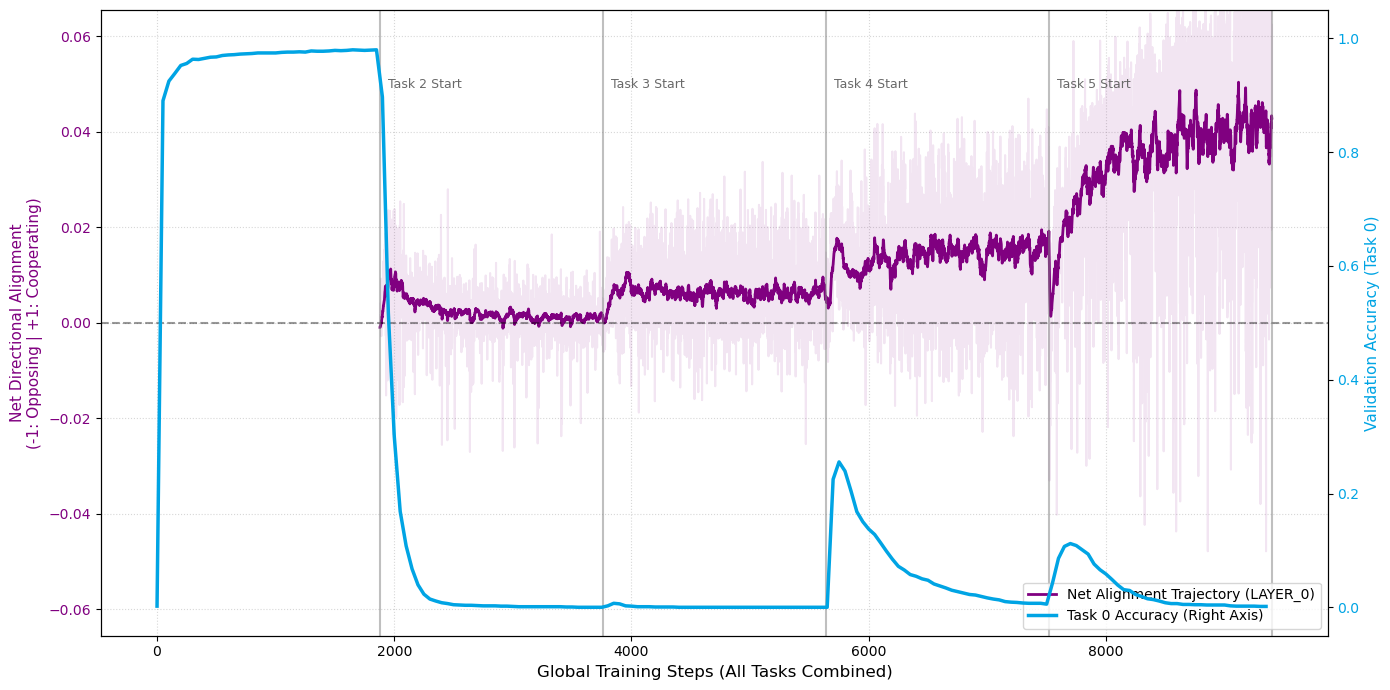

In [3]:
def plot_alignment_accuracy_overlay(tracker, target_task_idx=0, target_layer='layer_0', smoothing_alpha=0.05):
    """
    Overlays a specific task's accuracy curve directly on top of the Net Alignment score
    using a secondary y-axis for high-resolution correlation analysis.
    Supports multi-layer nested dictionary tracking metrics.

    Args:
        tracker: The AlignmentTracker instance holding run data.
        target_task_idx: The integer index of the historical task accuracy to overlay (e.g., 0 for Task 1).
        target_layer: The string key of the target layer (e.g., 'layer_0').
        smoothing_alpha: EMA smoothing coefficient for the gradient trend line.
    """
    import pandas as pd
    import matplotlib.pyplot as plt

    # Ensure the requested layer has tracking logs populated
    if target_layer not in tracker.net_alignments:
        print(f"No alignment history found for layer key: {target_layer}")
        return

    fig, ax1 = plt.subplots(figsize=(14, 7))
    steps = tracker.steps

    # Extract raw alignment array for the specific layer
    raw_alignments = tracker.net_alignments[target_layer]

    # --- LEFT AXIS: Net Alignment Score ---
    net_series = pd.Series(raw_alignments)
    smoothed_net = net_series.ewm(alpha=smoothing_alpha, adjust=False).mean().values

    # Plot faint raw alignment noise and heavy smoothed trajectory
    ax1.plot(steps, raw_alignments, color='purple', alpha=0.10)
    line_align, = ax1.plot(steps, smoothed_net, color='purple', linewidth=2,
                           label=f'Net Alignment Trajectory ({target_layer.upper()})')

    ax1.axhline(0, color='black', linestyle='--', alpha=0.4)
    ax1.set_xlabel('Global Training Steps (All Tasks Combined)', fontsize=12)
    ax1.set_ylabel('Net Directional Alignment\n(-1: Opposing | +1: Cooperating)', color='purple', fontsize=11)
    ax1.tick_params(axis='y', labelcolor='purple')
    ax1.grid(True, linestyle=':', alpha=0.5)

    # Automatically fit alignment limits with a clean symmetrical buffer
    align_bound = max(abs(min(smoothed_net)), abs(max(smoothed_net))) * 1.3
    ax1.set_ylim(-align_bound, align_bound)

    # --- RIGHT AXIS: Target Task Accuracy ---
    ax2 = ax1.twinx()  # Instantiate a companion axis that shares the same x-timeline

    acc_steps = tracker.acc_steps
    task_accs = tracker.accuracies[f'task_{target_task_idx}']

    # Plot the accuracy curve using a highly visible contrast color
    line_acc, = ax2.plot(acc_steps, task_accs, color='#00a4e4', linewidth=2.5,
                          label=f'Task {target_task_idx} Accuracy (Right Axis)')

    ax2.set_ylabel(f'Validation Accuracy (Task {target_task_idx})', color='#00a4e4', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='#00a4e4')
    ax2.set_ylim(-0.05, 1.05)

    # Combined Legend handling for overlapping twin axes
    lines = [line_align, line_acc]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='lower right')

    # Draw vertical task boundary lines across the shared coordinate grid
    for i, boundary_step in enumerate(tracker.task_boundaries):
        if i < len(tracker.task_boundaries):
            ax1.axvline(boundary_step, color='gray', linestyle='-', alpha=0.5)
            # Use data coordinates relative to the updated y-axis ceiling limits
            if i < len(tracker.task_boundaries) - 1:  # Avoid labeling beyond the last boundary
                ax1.text(boundary_step, align_bound * 0.75, f'  Task {i+2} Start', color='dimgray', fontsize=9)

    # plt.title(f'Direct Correlation: Net Alignment ({target_layer.upper()}) vs. Task {target_task_idx} Accuracy Decay Profile', fontsize=14, pad=15)
    plt.tight_layout()
    plt.savefig(f'leaky_gpm_overlay_{target_layer}_task_{target_task_idx}.pdf', bbox_inches='tight')
    plt.show()

# Execution Call
plot_alignment_accuracy_overlay(align_tracker, target_task_idx=0, target_layer='layer_0')

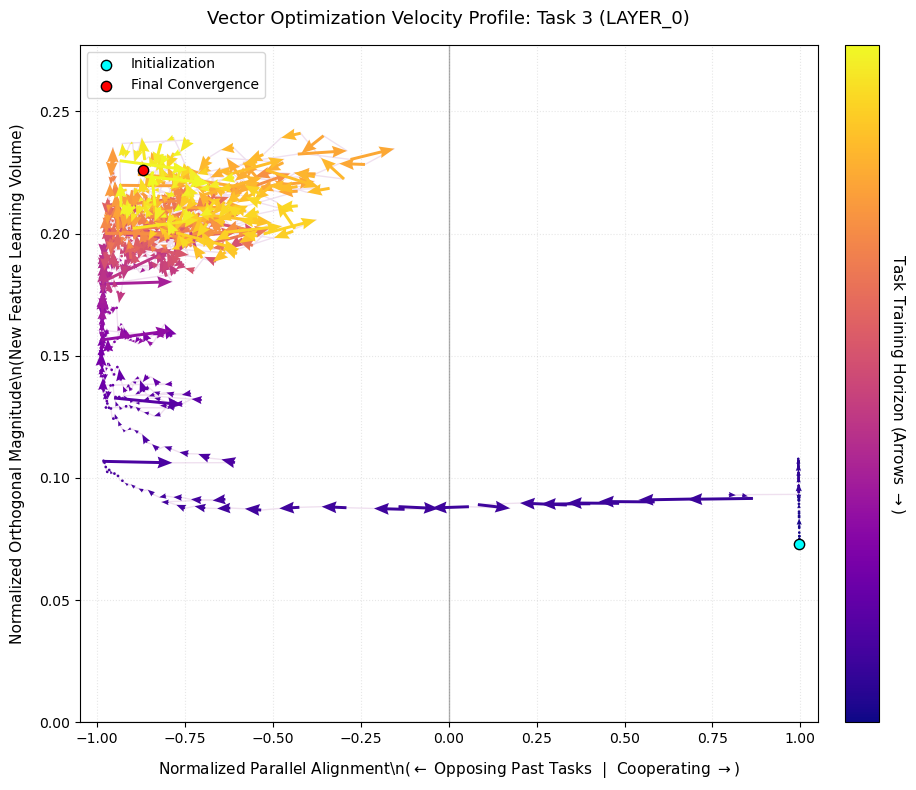

In [ ]:
%matplotlib inline

def plot_single_task_quiver(tracker, target_task_idx=2, target_layer='layer_0',
                            smoothing_alpha=0.1, arrow_stride=40):
    """
    Plots a static 2D phase portrait for a single task using quiver arrows,
    updated to fetch data from multi-layer dictionary metrics.
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    # 1. Map step boundaries for the targeted task block
    start_step_idx = 0 if target_task_idx == 0 else tracker.task_boundaries[target_task_idx - 1]
    end_step_idx = tracker.task_boundaries[target_task_idx]

    # 2. Isolate steps
    global_steps = np.array(tracker.steps)
    task_mask = (global_steps >= start_step_idx) & (global_steps < end_step_idx)
    sliced_steps = global_steps[task_mask]

    # 3. Safely extract vectors for the specified layer key
    if target_layer not in tracker.x_parallel_normalized:
        print(f"No tracking logs found for layer: {target_layer}")
        return

    x_raw = np.array(tracker.x_parallel_normalized[target_layer])[task_mask]
    y_raw = np.array(tracker.y_orthogonal_normalized[target_layer])[task_mask]

    if len(x_raw) == 0:
        print(f"No data points captured for {target_layer} during Task {target_task_idx + 1}.")
        return

    # 4. Smooth coordinates
    x_smoothed = pd.Series(x_raw).ewm(alpha=smoothing_alpha, adjust=False).mean().values
    y_smoothed = pd.Series(y_raw).ewm(alpha=smoothing_alpha, adjust=False).mean().values

    fig, ax = plt.subplots(figsize=(10, 8))

    # --- GEOMETRIC TRAILS ---
    ax.plot(x_smoothed, y_smoothed, color='purple', alpha=0.12, linewidth=1.0, zorder=1)

    dx = np.diff(x_smoothed)
    dy = np.diff(y_smoothed)
    quiver_indices = np.arange(0, len(dx), arrow_stride)

    x_pos = x_smoothed[quiver_indices]
    y_pos = y_smoothed[quiver_indices]
    u_dir = dx[quiver_indices]
    v_dir = dy[quiver_indices]

    colors = np.arange(len(quiver_indices))
    cmap = plt.get_cmap('plasma')

    quiver = ax.quiver(x_pos, y_pos, u_dir, v_dir, colors, cmap=cmap,
                       scale_units='xy', angles='xy', scale=1,
                       width=0.004, headwidth=4, headlength=5, zorder=3)

    cbar = fig.colorbar(quiver, ax=ax, pad=0.03)
    cbar.set_label(r'Task Training Horizon (Arrows $\rightarrow$)', fontsize=11, rotation=270, labelpad=20)
    cbar.set_ticks([])

    # System limits
    ax.set_xlim(-1.05, 1.05)
    ax.set_ylim(0.00, max(y_smoothed) * 1.15)
    ax.axhline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.3)
    ax.axvline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.3)
    ax.grid(True, linestyle=':', alpha=0.3)

    ax.set_xlabel(r'Normalized Parallel Alignment\n' + r'($\leftarrow$ Opposing Past Tasks  |  Cooperating $\rightarrow$)', fontsize=11, labelpad=10)
    ax.set_ylabel(r'Normalized Orthogonal Magnitude\n(New Feature Learning Volume)', fontsize=11, labelpad=10)
    ax.set_title(f'Vector Optimization Velocity Profile: Task {target_task_idx + 1} ({target_layer.upper()})', fontsize=13, pad=15)

    ax.scatter(x_smoothed[0], y_smoothed[0], color='cyan', edgecolor='black', s=55, zorder=5, label='Initialization')
    ax.scatter(x_smoothed[-1], y_smoothed[-1], color='red', edgecolor='black', s=55, zorder=5, label='Final Convergence')
    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

plot_single_task_quiver(align_tracker, target_task_idx=4, target_layer='layer_0', arrow_stride=2)

In [ ]:
# --- Configuration ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
TASKS = [[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]]
LR = 1e-2
GAMMA = 0.001
K_STEEPNESS = 3000.0
BATCH_SIZE = 64 # Increased for GPU efficiency
EPOCHS_PER_TASK = 10

class EbbinghausOptimizer:
    def __init__(self, model, lr=LR, gamma=GAMMA, k_max=K_STEEPNESS, k_min=10):
        self.params = [p for p in model.parameters() if p.requires_grad]
        self.lr = lr
        self.gamma = gamma
        self.k_max = k_max
        self.k_min = k_min
        self.k_layers = []
        for i in range(len(self.params)):
            # Linear example:
            ratio = i / (len(self.params) - 1)
            k_val = self.k_max - ratio * (self.k_max - self.k_min)
            self.k_layers.append(k_val)
        # Stability accumulator S_i
        self.stability = [torch.zeros_like(p, device=DEVICE) for p in self.params]

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None: continue

                # 1. Dynamic Decay (Standard)
                # We can stick to a simpler decay here since the growth is self-regulating
                self.stability[i] = (1.0 - self.gamma) * self.stability[i]

                # 2. Saturating Growth (Diminishing Returns)
                # The 'fuller' the memory, the harder it is to add more.
                grad_sq = p.grad ** 2
                growth_resistance = 1.0 + self.stability[i]
                self.stability[i] += grad_sq / growth_resistance

                # 3. Calculate Hyperbolic Plasticity Filter
                plasticity = 1.0 / (1.0 + self.k_layers[i] * self.stability[i])

                # 4. Apply Filtered Update
                p.data -= self.lr * plasticity * p.grad

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.detach_()
                p.grad.zero_()

# --- 2. Training Loop ---
model = SimpleMLP().to(DEVICE)
ebbinghaus_opt = EbbinghausOptimizer(model)
criterion = nn.CrossEntropyLoss()
tracker = MetricsTracker()
total_steps = 0

(train_x, train_y), (test_x, test_y) = get_gpu_mnist()
all_test_tasks = [get_task_data(test_x, test_y, t) for t in TASKS]
results_matrix = []

for t_idx, digits in enumerate(TASKS):
    tx, ty = get_task_data(train_x, train_y, digits)
    print(f"Training Task {t_idx} (Digits {digits})")

    for epoch in range(EPOCHS_PER_TASK):
        indices = torch.randperm(len(tx))
        for i in range(0, len(tx), BATCH_SIZE):
            batch_idx = indices[i:i+BATCH_SIZE]
            bx, by = tx[batch_idx], ty[batch_idx]

            ebbinghaus_opt.zero_grad()
            output = model(bx)
            loss = criterion(output, by)
            loss.backward()

            # This is where the magic happens: No penalty, just a filtered step
            ebbinghaus_opt.step()

            total_steps += 1

            # High-Resolution Intra-Task Tracking
            if total_steps % EVAL_EVERY_N_BATCHES == 0:
                current_accs = evaluate(model, all_test_tasks)
                tracker.log(total_steps, current_accs, loss.item(), ebbinghaus_opt.stability)

        current_accs = evaluate(model, all_test_tasks)
        print(f"Epoch {epoch} Accuracies: {[round(a, 2) for a in current_accs]}")

    results_matrix.append(current_accs)

Training Task 0 (Digits [0, 1])
Epoch 0 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 1 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 2 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 3 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 4 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 5 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 6 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 7 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 8 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 9 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Training Task 1 (Digits [2, 3])
Epoch 0 Accuracies: [1.0, 0.0, 0.0, 0.0, 0.0]
Epoch 1 Accuracies: [1.0, 0.24, 0.0, 0.0, 0.0]
Epoch 2 Accuracies: [0.99, 0.72, 0.0, 0.0, 0.0]
Epoch 3 Accuracies: [0.97, 0.88, 0.0, 0.0, 0.0]
Epoch 4 Accuracies: [0.92, 0.92, 0.0, 0.0, 0.0]
Epoch 5 Accuracies: [0.82, 0.94, 0.0, 0.0, 0.0]
Epoch 6 Accuracies: [0.57, 0.94, 0.0, 0.0, 0.0]
Epoch 7 Accuracies: [0.31, 0.95, 0.0, 0.0, 0.0]
Epoch 8 Accuracies: [0.23, 0.95, 0.0, 0.0, 0.0]
Epoch 9 Accuracies: [0.19, 0.95, 0.0, 0.0, 0.0]

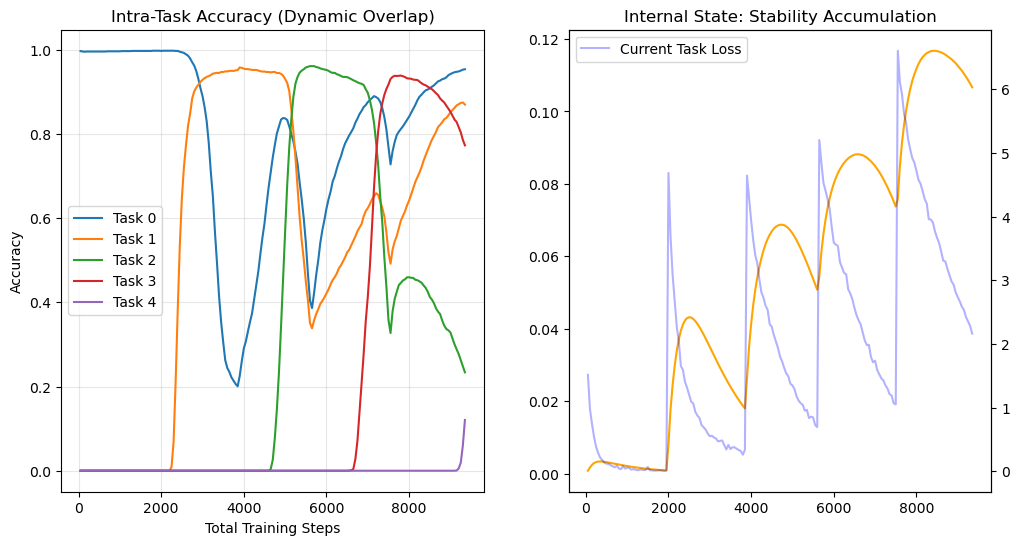

In [ ]:
def plot_research_results(tracker):
    steps = tracker.history['steps']
    accs = np.array(tracker.history['accuracies'])

    plt.figure(figsize=(12, 6))

    # 1. Learning Curves (All Tasks)
    plt.subplot(1, 2, 1)
    for i in range(len(TASKS)):
        plt.plot(steps, accs[:, i], label=f'Task {i}')

    # Draw vertical lines for task boundaries
    steps_per_task = (len(train_x)//len(TASKS)//BATCH_SIZE) * EPOCHS_PER_TASK
    # (Note: This is an approximation; calculate exactly based on your split sizes)

    plt.title("Intra-Task Accuracy (Dynamic Overlap)")
    plt.xlabel("Total Training Steps")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)

    # 2. Stability Growth vs. Loss
    plt.subplot(1, 2, 2)
    plt.plot(steps, tracker.history['stability_means'], label='Mean Stability (S)', color='orange')
    plt.twinx()
    plt.plot(steps, tracker.history['losses'], label='Current Task Loss', color='blue', alpha=0.3)
    plt.title("Internal State: Stability Accumulation")
    plt.xlabel("Total Training Steps")
    plt.legend()
    plt.show()

plot_research_results(tracker)